# **Importing** **Libraries**

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import os

plt.rcParams["figure.figsize"] = (10,5)

# **Load Dataset**

In [51]:
df = pd.read_csv("../dataset/annotations.csv")

print(df.head())
print(df.shape)

              image_name                                      image_path  \
0  00035_00000_00000.png  dataset\train\Ahead_only\00035_00000_00000.png   
1  00035_00000_00002.png  dataset\train\Ahead_only\00035_00000_00002.png   
2  00035_00000_00003.png  dataset\train\Ahead_only\00035_00000_00003.png   
3  00035_00000_00004.png  dataset\train\Ahead_only\00035_00000_00004.png   
4  00035_00000_00005.png  dataset\train\Ahead_only\00035_00000_00005.png   

   split  class_id  class_name  
0  train      35.0  Ahead_only  
1  train      35.0  Ahead_only  
2  train      35.0  Ahead_only  
3  train      35.0  Ahead_only  
4  train      35.0  Ahead_only  
(51839, 5)


# **Class Distribution**

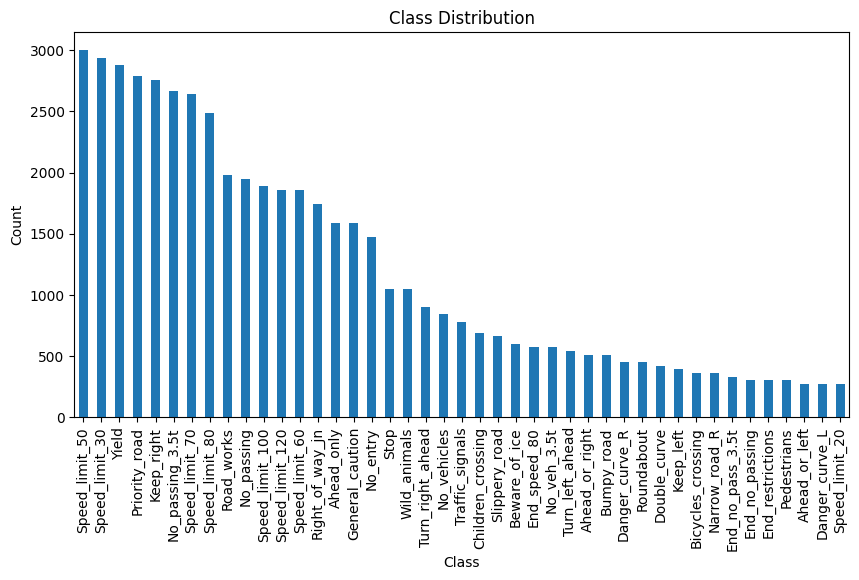

In [52]:
class_counts = df["class_name"].value_counts()

class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# **Split Distribution**

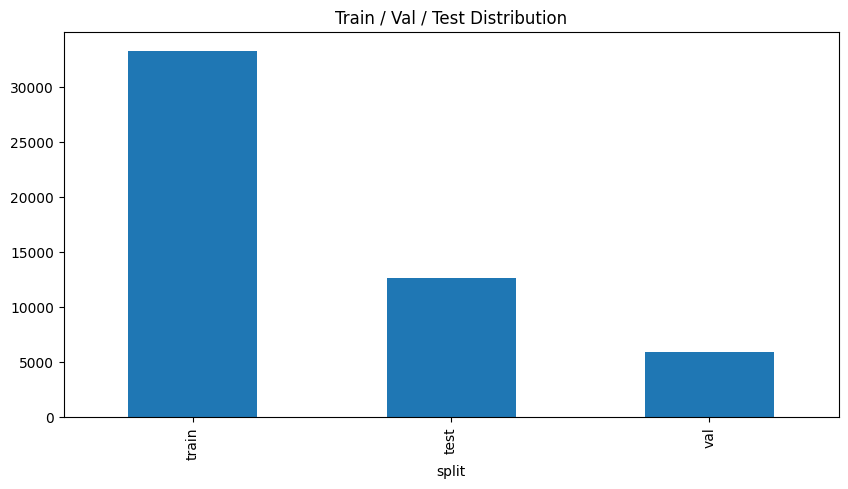

In [53]:
df["split"].value_counts().plot(kind="bar")
plt.title("Train / Val / Test Distribution")
plt.show()

# **Class Distribution per Split**

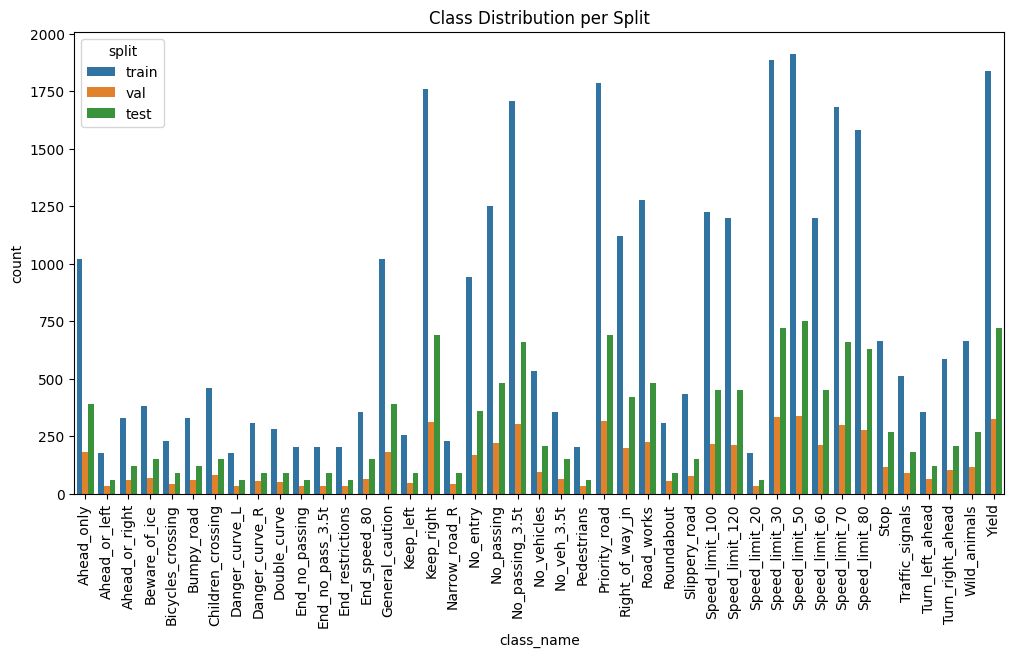

In [54]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="class_name", hue="split")
plt.xticks(rotation=90)
plt.title("Class Distribution per Split")
plt.show()

# **Top 10 Classes**

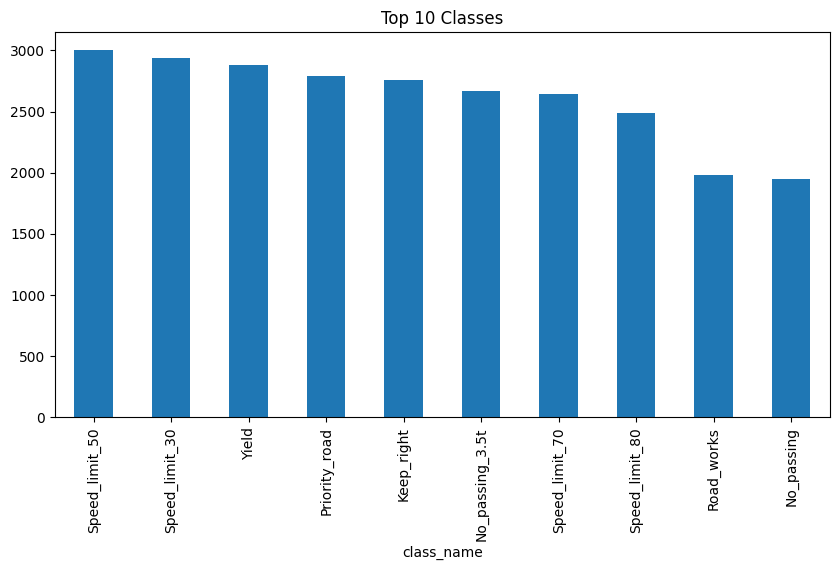

In [55]:
class_counts.head(10).plot(kind="bar")
plt.title("Top 10 Classes")
plt.show()

# **Bottom 10 Classes**

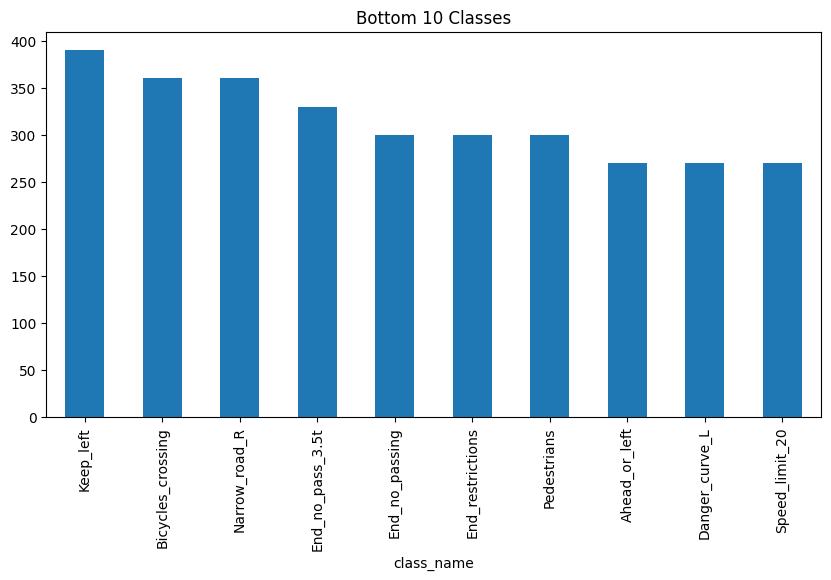

In [56]:
class_counts.tail(10).plot(kind="bar")
plt.title("Bottom 10 Classes")
plt.show()

# **Imbalance Ratio**

In [57]:
imbalance_ratio = class_counts.max() / class_counts.min()

print("Max class:", class_counts.idxmax())
print("Min class:", class_counts.idxmin())
print("Imbalance Ratio:", imbalance_ratio)

Max class: Speed_limit_50
Min class: Ahead_or_left
Imbalance Ratio: 11.11111111111111


# **Sample Images**

In [60]:
from pathlib import Path

BASE_DIR = Path(r"D:/AML_Project")

# 1) توحيد slashes + إزالة duplication لو موجود
df["image_path"] = df["image_path"].astype(str)

df["image_path"] = df["image_path"].str.replace("\\", "/", regex=False)
df["image_path"] = df["image_path"].str.replace("dataset/dataset", "dataset")

# 2) بناء absolute path بشكل نظيف
df["image_path"] = df["image_path"].apply(lambda x: str(BASE_DIR / x))


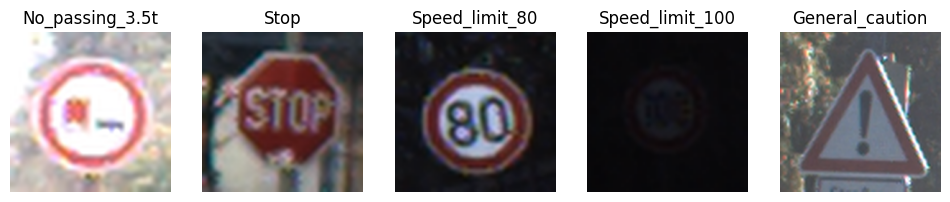

In [62]:
def show_samples(df, n=5):
    sample = df.sample(n)

    plt.figure(figsize=(12,3))
    for i, row in enumerate(sample.itertuples()):
        img = cv2.imread(row.image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(row.class_name)
        plt.axis("off")

    plt.show()

show_samples(df)

# **Image Size Distribution**

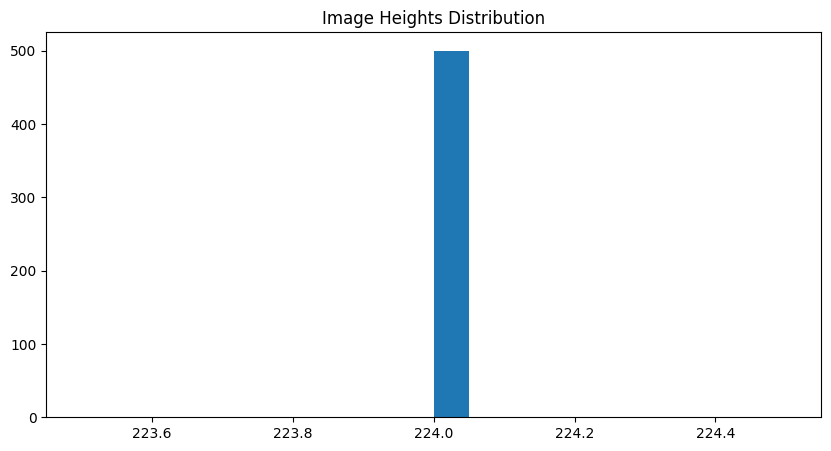

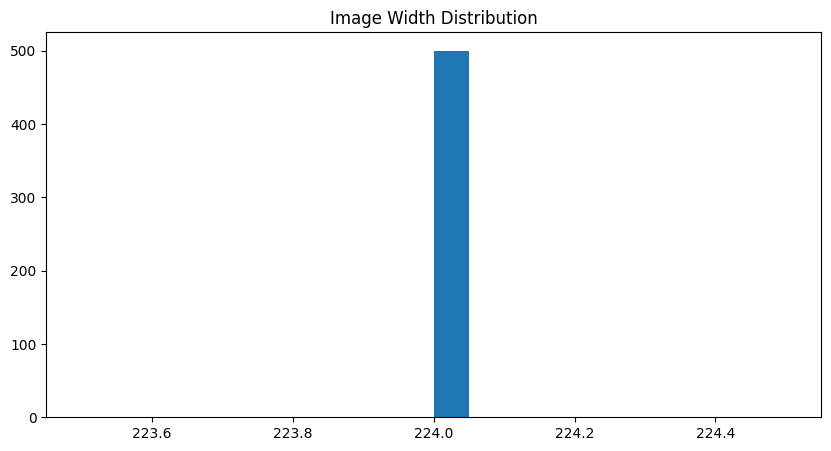

In [63]:
sizes = []

for path in df["image_path"].sample(500):
    img = cv2.imread(path)
    if img is not None:
        sizes.append(img.shape[:2])

heights = [s[0] for s in sizes]
widths = [s[1] for s in sizes]

plt.hist(heights, bins=20)
plt.title("Image Heights Distribution")
plt.show()

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

# **Percentage Distribution**

In [66]:
percentages = (class_counts / class_counts.sum()) * 100

print(percentages.head(10))

class_name
Speed_limit_50     5.787149
Speed_limit_30     5.671406
Yield              5.555663
Priority_road      5.382048
Keep_right         5.324177
No_passing_3.5t    5.150562
Speed_limit_70     5.092691
Speed_limit_80     4.803333
Road_works         3.819518
No_passing         3.761647
Name: count, dtype: float64


# **Heatmap**

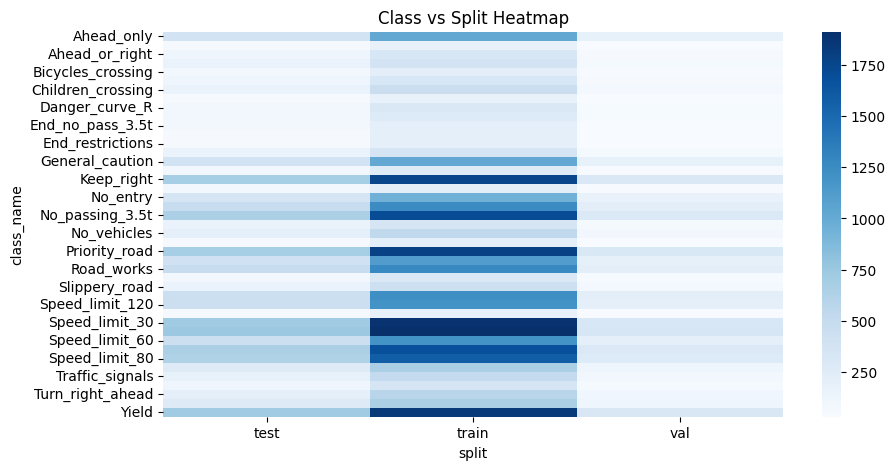

In [67]:
pivot = pd.crosstab(df["class_name"], df["split"])

sns.heatmap(pivot, cmap="Blues")
plt.title("Class vs Split Heatmap")
plt.show()